In [4]:
import pandas as pd 
df = pd.read_csv('heart.csv')
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [11]:
import pandas as pd 
import numpy as np
 # Load data
df = pd.read_csv("Heart_disease_cleveland_new.csv")
df = df.replace('?', np.nan) 
df = df.apply(pd.to_numeric)
df = df.fillna(df.mean())
Q1 = df.quantile(0.25) 
Q3 = df.quantile(0.75) 
IQR = Q3 - Q1 
lower = Q1 - 1.5 * IQR 
upper = Q3 + 1.5 * IQR 
outliers = ((df < lower) | (df > upper)) 
print("Outlier rows:") 
print(df[outliers.any(axis=1)])
df = df[~outliers.any(axis=1)] 
print("After removing outliers:", df.shape) 
X = df.drop("target", axis=1)
y = df["target"] 
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2) 
from sklearn.preprocessing import MinMaxScaler

Outlier rows:
     age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
0     63    1   0       145   233    1        2      150      0      2.3   
1     67    1   3       160   286    0        2      108      1      1.5   
9     53    1   3       140   203    1        2      155      1      3.1   
12    56    1   2       130   256    1        2      142      1      0.6   
14    52    1   2       172   199    1        0      162      0      0.5   
..   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
285   58    1   3       114   318    0        1      140      0      4.4   
286   58    0   3       170   225    1        2      146      1      2.8   
296   59    1   3       164   176    1        2       90      0      1.0   
298   45    1   0       110   264    0        0      132      0      1.2   
299   68    1   3       144   193    1        0      141      0      3.4   

     slope  ca  thal  target  
0        2   0     2       0  
1        1 

In [12]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import * 
model = DecisionTreeClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test) 
print("Decision Tree") 
print("Confusion Matrix:") 
print(confusion_matrix(y_test, y_pred)) 
print("Accuracy:", accuracy_score(y_test, y_pred))

Decision Tree
Confusion Matrix:
[[18  8]
 [10  8]]
Accuracy: 0.5909090909090909


Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.82      0.82       125
           1       0.76      0.76      0.76        91

    accuracy                           0.80       216
   macro avg       0.79      0.79      0.79       216
weighted avg       0.80      0.80      0.80       216

Confusion Matrix:
[[103  22]
 [ 22  69]]


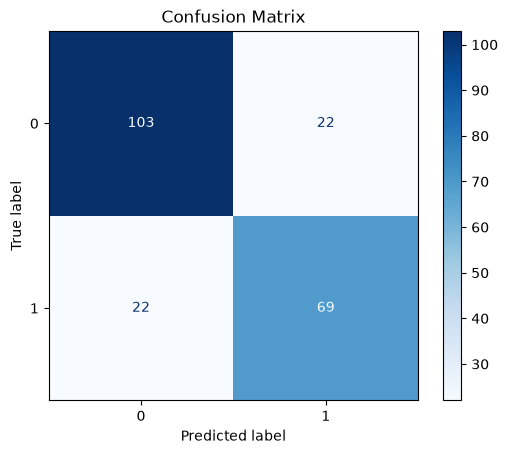

In [13]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.tree import DecisionTreeClassifier

# 5-Fold Stratified Cross Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Create model
model = DecisionTreeClassifier(random_state=42)

# Generate cross-validated predictions
y_pred = cross_val_predict(model, X, y, cv=skf)

# Classification Report
print("Classification Report:")
print(classification_report(y, y_pred))

# Confusion Matrix
cm = confusion_matrix(y, y_pred)
print("Confusion Matrix:")
print(cm)

# Visualize Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)

plt.title("Confusion Matrix")
plt.show()

--- NAIVE BAYES REPORT ---
              precision    recall  f1-score   support

           0       0.81      0.84      0.83       160
           1       0.81      0.77      0.79       140

    accuracy                           0.81       300
   macro avg       0.81      0.81      0.81       300
weighted avg       0.81      0.81      0.81       300

--- SVM REPORT ---
              precision    recall  f1-score   support

           0       0.98      0.93      0.95       160
           1       0.92      0.98      0.95       140

    accuracy                           0.95       300
   macro avg       0.95      0.95      0.95       300
weighted avg       0.95      0.95      0.95       300



C:\Users\ACEEC\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


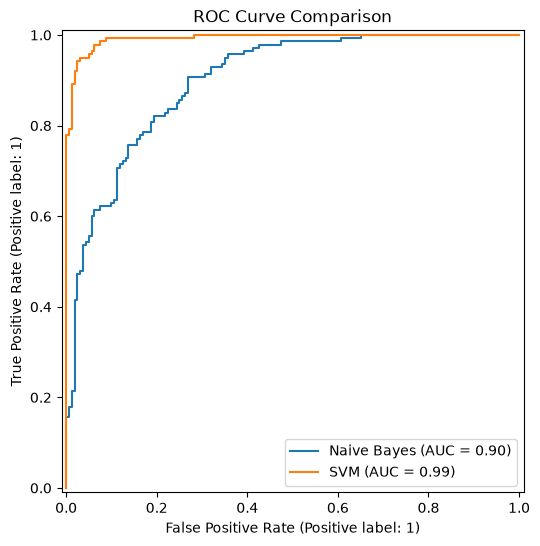

In [14]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import classification_report, RocCurveDisplay

# Generate sample dataset
X, y = make_classification(
    n_samples=1000,
    n_features=20,
    n_informative=10,
    n_redundant=5,
    random_state=42
)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Create models
nb = GaussianNB()
svm = SVC(probability=True, random_state=42)

# Train and evaluate Naive Bayes
nb.fit(X_train, y_train)
print("--- NAIVE BAYES REPORT ---")
print(classification_report(y_test, nb.predict(X_test)))

# Train and evaluate SVM
svm.fit(X_train, y_train)
print("--- SVM REPORT ---")
print(classification_report(y_test, svm.predict(X_test)))

# Plot ROC Curves
fig, ax = plt.subplots(figsize=(8, 6))

RocCurveDisplay.from_estimator(
    nb, X_test, y_test, ax=ax, name="Naive Bayes"
)

RocCurveDisplay.from_estimator(
    svm, X_test, y_test, ax=ax, name="SVM"
)

plt.title("ROC Curve Comparison")
plt.show()

In [15]:
import numpy as np
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Generate sample regression dataset
X, y = make_regression(
    n_samples=100,
    n_features=5,
    noise=10,
    random_state=42
)

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Train Linear Regression model
lr = LinearRegression()
lr.fit(X_train, y_train)

# Make predictions
lr_pred = lr.predict(X_test)

# Evaluate model
print("--- LINEAR REGRESSION RESULTS ---")
print("MAE :", mean_absolute_error(y_test, lr_pred))
print("MSE :", mean_squared_error(y_test, lr_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, lr_pred)))
print("R²  :", r2_score(y_test, lr_pred))

--- LINEAR REGRESSION RESULTS ---
MAE : 8.437614476433842
MSE : 113.44800318060754
RMSE: 10.65119726512506
R²  : 0.9944099738323339
